# [Title of the report]


[It is ideal to include a table of contents here to organise content with the right level of heading and sub-headings; makes it much easier to read for your audience. Use the right level of headings (Heading 1, Heading 2 etc.) to preserve hierarchy
]

Impt note: The template only provides sample blocks to ensure you cover the basic requirements of this assignment; you are free to adapt it to your need as required.

## Introduction

[Provide a short paragraph providing background to your analysis, explaining your aims and context. Include specific questions of inquiry, if any]

## Data Ingestion

[Describe your input data set, and provide a high-level explanation of the steps in your code]

In [ ]:
#Add code to ingest data
import os
from pathlib import Path
import pandas as pd
import pdfplumber
from tqdm import tqdm
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import seaborn as sns

In [ ]:


# Definir la ruta de entrada (donde están tus PDFs) y de salida
RAW_DATA_PATH = Path("/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/raw") # o Path("data/raw") según dónde guardes el notebook
PROCESSED_DATA_PATH = Path("/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed")

In [7]:
def extraer_texto_pdf(RAW_DATA_PATH):
    """
    Lee un PDF usando pdfplumber y une el texto de todas sus páginas.
    """
    texto_completo = []
    try:
        with pdfplumber.open(RAW_DATA_PATH) as pdf:
            for pagina in pdf.pages:
                texto_pagina = pagina.extract_text()
                if texto_pagina:
                    texto_completo.append(texto_pagina)
        # Unir todas las páginas con un salto de línea
        return "\n".join(texto_completo)
    except Exception as e:
        print(f"Error al leer {RAW_DATA_PATH.name}: {e}")
        return None

In [8]:
registros = []

# Obtener todos los archivos .pdf en la carpeta raw
archivos_pdf = list(RAW_DATA_PATH.glob("*.pdf"))
print(f"Se encontraron {len(archivos_pdf)} archivos PDF.")

# Procesar cada archivo con barra de progreso
for pdf_path in tqdm(archivos_pdf, desc="Procesando PDFs"):
    contenido = extraer_texto_pdf(pdf_path)
    
    if contenido:
        registros.append({
            "archivo": pdf_path.name,
            "tamano_bytes": pdf_path.stat().st_size,
            "texto_raw": contenido,
            "caracteres_totales": len(contenido)
        })

# Convertir a DataFrame de Pandas
df = pd.DataFrame(registros)
print(f"\n¡Éxito! Se procesaron {len(df)} PDFs correctamente.")
df.head()

Se encontraron 143 archivos PDF.


Procesando PDFs: 100%|██████████| 143/143 [01:59<00:00,  1.19it/s]


¡Éxito! Se procesaron 143 PDFs correctamente.


,archivo,tamano_bytes,texto_raw,caracteres_totales
0,Sub106.pdf,497475,Inquiry into the value of skilled migration to...,51052
1,Sub112.pdf,549895,Inquiry into the value of skilled migration to...,32986
2,Sub072.pdf,1913552,Inquiry into the value of skilled migration to...,11405
3,Sub066.pdf,493749,Inquiry into the value of skilled migration to...,16048
4,Sub099.pdf,349200,Inquiry into the value of skilled migration to...,23379


In [15]:
from pathlib import Path

# 1. Aseguramos que la variable sea un objeto Path (reemplaza con tu ruta exacta si es diferente)
PROCESSED_DATA_PATH = Path("/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed")

# 2. Ahora sí, creamos la carpeta
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# 3. Definimos el nombre del archivo final
archivo_salida = PROCESSED_DATA_PATH / "submissions_extraidas.csv"

# 4. Guardamos el DataFrame como CSV
df.to_csv(archivo_salida, index=False)

print(f"¡Tus datos están a salvo! Se guardaron en:\n{archivo_salida}")

¡Tus datos están a salvo! Se guardaron en:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_extraidas.csv


In [17]:
# Descargar las herramientas de NLTK necesarias (solo se descarga la primera vez)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Definir la ruta de tu archivo CSV procesado
PROCESSED_DATA_PATH = "/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_extraidas.csv" 

# Cargar los datos extraídos en el paso anterior
df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Dataset cargado con {len(df)} filas.")

Dataset cargado con 143 filas.


[nltk_data] Downloading package punkt to /Users/diegoz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/diegoz/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/diegoz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:



print("Cleaning text data...")
df['texto_limpio'] = df['texto_raw'].apply(clean_text)
print("Text cleaning complete!")

Cleaning text data...
Text cleaning complete!


## Exploratory data analysis

[Add details]



In [ ]:
#Code block with appropriate comments for documentation

### 1. Basic Analysis

[Add sub-headers as needed to highlight the kinds of analysis done]

--- DATASET OVERVIEW ---
Total rows (documents): 143

Column data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   archivo             143 non-null    object 
 1   tamano_bytes        143 non-null    int64  
 2   texto_raw           143 non-null    object 
 3   caracteres_totales  143 non-null    int64  
 4   texto_limpio        143 non-null    object 
 5   char_count          143 non-null    int64  
 6   word_count          143 non-null    int64  
 7   avg_word_length     143 non-null    float64
dtypes: float64(1), int64(4), object(3)
memory usage: 9.1+ KB

Missing raw texts: 0

--- DESCRIPTIVE STATISTICS ---
          char_count    word_count  avg_word_length
count     143.000000    143.000000       143.000000
mean    26641.503497   3746.216783         6.119381
std     38888.869984   5645.991148       

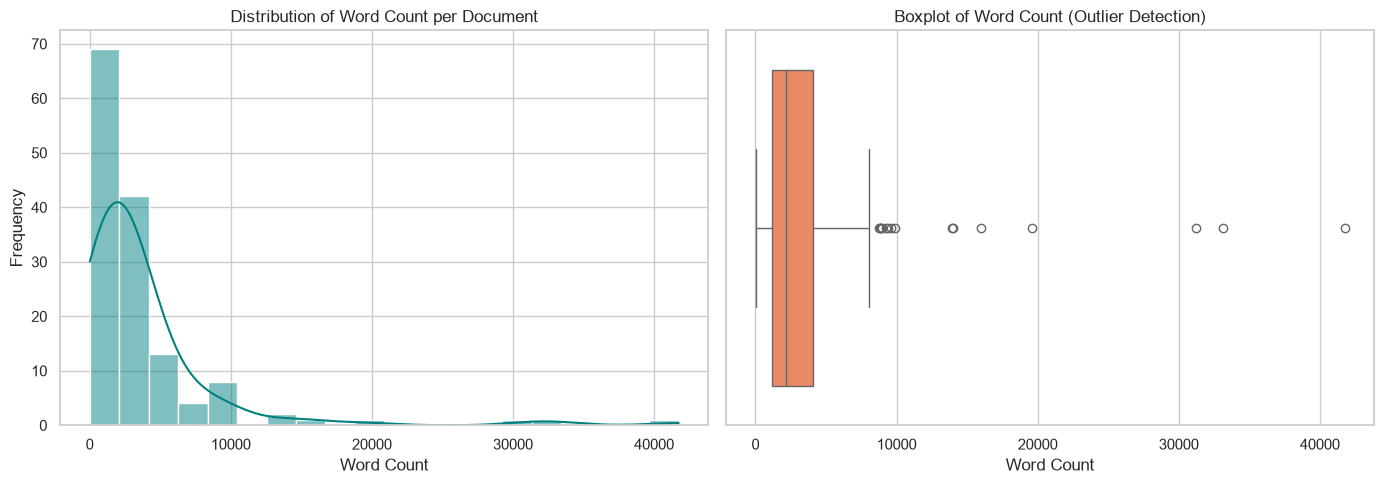

In [22]:
# --- 1. GENERAL DATASET OVERVIEW ---
# Display basic dataframe structural information
print("--- DATASET OVERVIEW ---")
print(f"Total rows (documents): {len(df)}")
print("\nColumn data types and non-null counts:")
df.info()

# Check for missing values in text column
missing_texts = df['texto_raw'].isna().sum()
print(f"\nMissing raw texts: {missing_texts}")


# --- 2. TEXT LENGTH & METRICS COMPUTATION ---
# Calculate document statistics on raw text
df['char_count'] = df['texto_raw'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['word_count'] = df['texto_raw'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df['avg_word_length'] = df['texto_raw'].apply(
    lambda x: sum(len(word) for word in str(x).split()) / len(str(x).split()) if pd.notna(x) and len(str(x).split()) > 0 else 0
)

# Display statistical summary of text length metrics
print("\n--- DESCRIPTIVE STATISTICS ---")
print(df[['char_count', 'word_count', 'avg_word_length']].describe())


# --- 3. IDENTIFYING EXTREME DOCUMENTS (OUTLIERS) ---
# Inspect the shortest documents (potential empty/scanned PDFs)
print("\n--- 5 SHORTEST DOCUMENTS BY WORD COUNT ---")
print(df[['archivo', 'word_count', 'char_count']].sort_values(by='word_count').head())

# Inspect the longest documents
print("\n--- 5 LONGEST DOCUMENTS BY WORD COUNT ---")
print(df[['archivo', 'word_count', 'char_count']].sort_values(by='word_count', ascending=False).head())


# --- 4. VISUALIZATION OF TEXT METRICS ---
# Set visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of word counts across submissions
sns.histplot(df['word_count'], kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('Distribution of Word Count per Document')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

# Boxplot to identify length outliers
sns.boxplot(x=df['word_count'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot of Word Count (Outlier Detection)')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

[Along with every code block, it is mandatory to provide a text explanation to expand on your results. Do not leave interpreting the results to your reader!]

### 1.1 Pre-processing

[Detailed steps, justification, custom stopwords, etc ..]

In [23]:
# --- STEP 1: TEXT CLEANING FUNCTION ---
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Cleans raw text by converting to lowercase, removing punctuation/numbers,
    tokenizing, and removing stopwords.
    """
    if not isinstance(text, str):
        return ""
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize the text into individual words
    words = word_tokenize(text)
    
    # Remove stopwords and short words (length <= 2)
    clean_words = [word for word in words if word not in stop_words and len(word) > 2]
    
    # Rejoin words into a single string
    return " ".join(clean_words)

# Apply the cleaning function to create a new column

### 1.2 Word frequencies [...]

description, code, results and charts, explanation

=== CORPUS LEXICAL SUMMARY ===
Total Tokens (Word instances): 342,111
Vocabulary Size (Unique words): 13,429
Type-Token Ratio (TTR - Lexical Diversity): 0.0393
Hapax Legomena (Words appearing only once): 4,582

=== TOP 20 WORDS WITH ADVANCED METRICS ===
         word  frequency  corpus_percentage  document_count  document_percentage  word_length
    migration       8089           2.364437             143           100.000000            9
      skilled       7509           2.194902             143           100.000000            7
    australia       7488           2.188763             143           100.000000            9
         visa       3060           0.894447             123            86.013986            4
       skills       2962           0.865801             127            88.811189            6
        value       2517           0.735726             143           100.000000            5
   australian       2461           0.719357             129            90.209790        

/var/folders/yw/kp044r9x1_ng_k9xgwn3blr80000gn/T/ipykernel_38895/295702489.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, x='frequency', y='word', ax=axes[0, 0], palette='Blues_r')
/var/folders/yw/kp044r9x1_ng_k9xgwn3blr80000gn/T/ipykernel_38895/295702489.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, x='document_percentage', y='word', ax=axes[0, 1], palette='Greens_r')


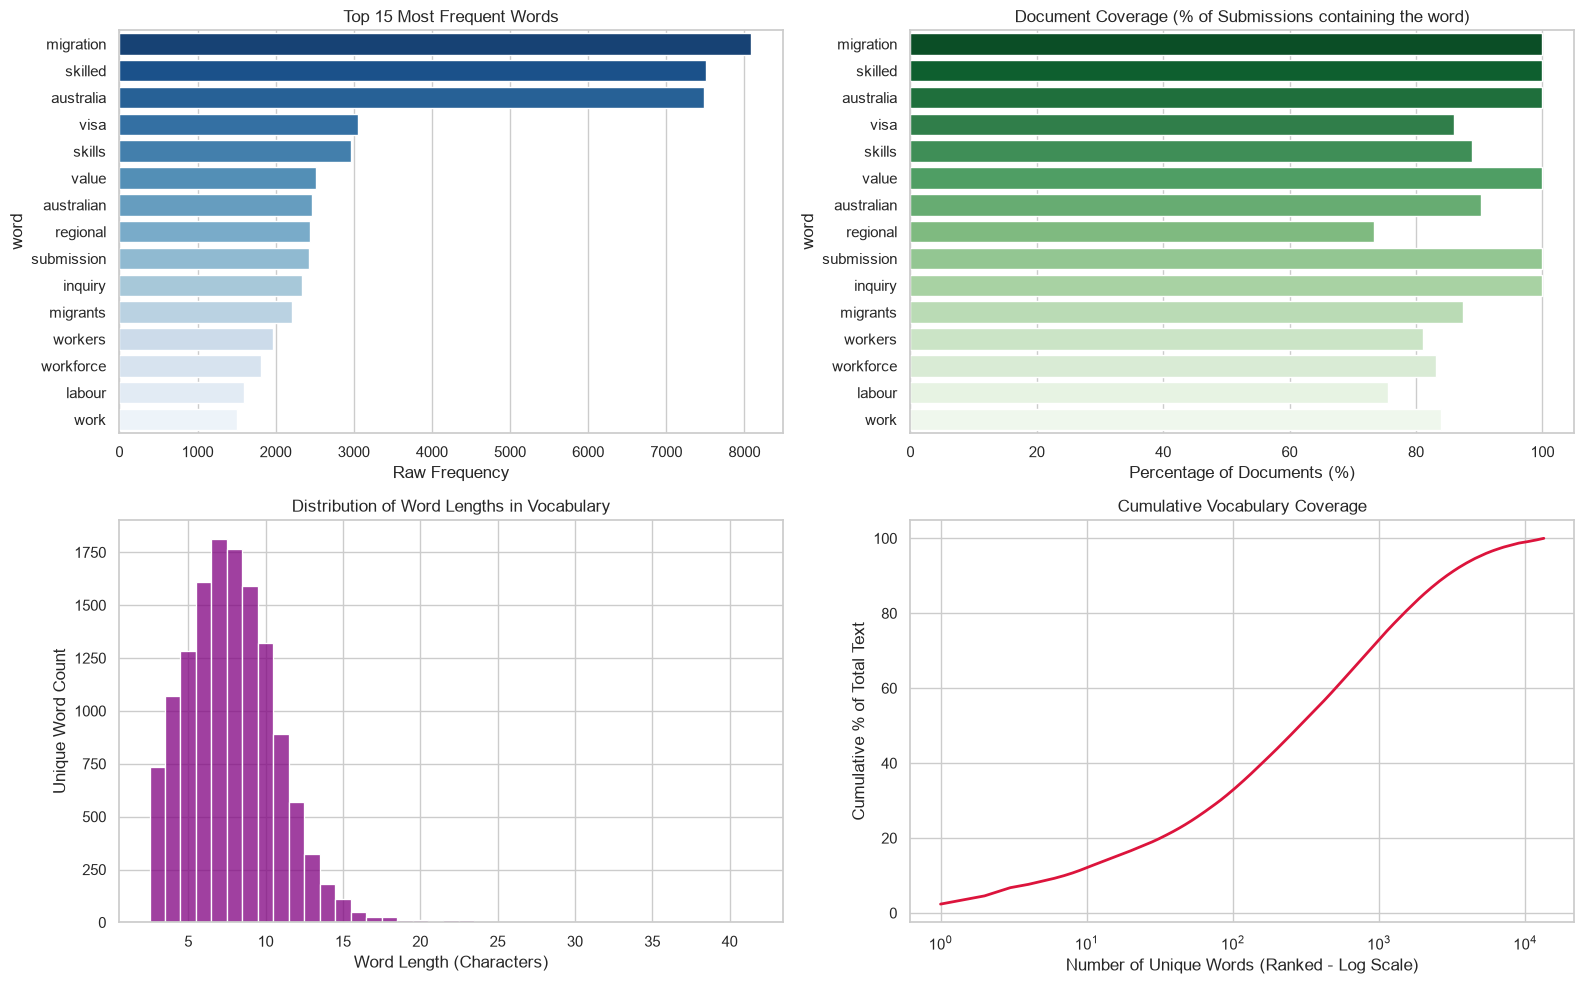

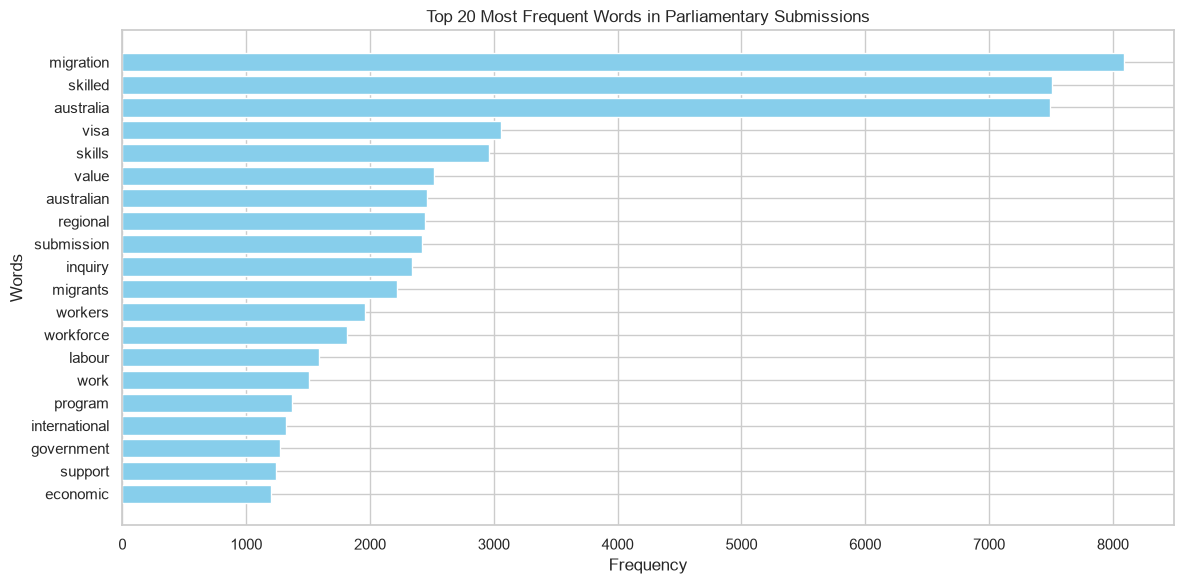

In [25]:
# --- 1. TOKENIZATION & FREQUENCY COMPUTATION ---
# Combine all cleaned text into a single string
all_text = " ".join(df['texto_limpio'].dropna())

# Split text into individual tokens
tokens = all_text.split()

# Compute word frequencies
word_counts = Counter(tokens)

# Convert frequency data into a DataFrame
df_frequencies = pd.DataFrame(word_counts.items(), columns=['word', 'frequency'])
df_frequencies = df_frequencies.sort_values(by='frequency', ascending=False).reset_index(drop=True)


# --- 2. ADVANCED LEXICAL METRICS ---
# Total number of words in the corpus (Tokens)
total_tokens = len(tokens)

# Total number of unique words (Types / Vocabulary Size)
vocabulary_size = len(word_counts)

# Type-Token Ratio (TTR): Measures lexical diversity
ttr = vocabulary_size / total_tokens if total_tokens > 0 else 0

# Percentage contribution of each word to the total corpus
df_frequencies['corpus_percentage'] = (df_frequencies['frequency'] / total_tokens) * 100

# Document Frequency (DF): Count in how many documents each word appears
doc_frequency = df['texto_limpio'].dropna().apply(lambda x: set(x.split()))
word_doc_counts = Counter([word for doc in doc_frequency for word in doc])

df_frequencies['document_count'] = df_frequencies['word'].map(word_doc_counts)
df_frequencies['document_percentage'] = (df_frequencies['document_count'] / len(df)) * 100

# Add word length metric
df_frequencies['word_length'] = df_frequencies['word'].apply(len)


# --- 3. CORPUS SUMMARY REPORT ---
print("=== CORPUS LEXICAL SUMMARY ===")
print(f"Total Tokens (Word instances): {total_tokens:,}")
print(f"Vocabulary Size (Unique words): {vocabulary_size:,}")
print(f"Type-Token Ratio (TTR - Lexical Diversity): {ttr:.4f}")
print(f"Hapax Legomena (Words appearing only once): {sum(1 for v in word_counts.values() if v == 1):,}")
print("=" * 35)

print("\n=== TOP 20 WORDS WITH ADVANCED METRICS ===")
print(df_frequencies.head(20).to_string(index=False))


# --- 4. MULTI-PANEL VISUALIZATION DASHBOARD ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Chart 1: Top 15 Most Frequent Words
top_15 = df_frequencies.head(15)
sns.barplot(data=top_15, x='frequency', y='word', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Top 15 Most Frequent Words')
axes[0, 0].set_xlabel('Raw Frequency')

# Chart 2: Document Coverage (%) of Top 15 Words
sns.barplot(data=top_15, x='document_percentage', y='word', ax=axes[0, 1], palette='Greens_r')
axes[0, 1].set_title('Document Coverage (% of Submissions containing the word)')
axes[0, 1].set_xlabel('Percentage of Documents (%)')

# Chart 3: Word Length vs Frequency Distribution
sns.histplot(df_frequencies['word_length'], discrete=True, kde=False, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribution of Word Lengths in Vocabulary')
axes[1, 0].set_xlabel('Word Length (Characters)')
axes[1, 0].set_ylabel('Unique Word Count')

# Chart 4: Cumulative Corpus Coverage (Zipf\'s Law representation)
df_frequencies['cumulative_percentage'] = df_frequencies['corpus_percentage'].cumsum()
axes[1, 1].plot(range(1, len(df_frequencies) + 1), df_frequencies['cumulative_percentage'], color='crimson', lw=2)
axes[1, 1].set_title('Cumulative Vocabulary Coverage')
axes[1, 1].set_xlabel('Number of Unique Words (Ranked - Log Scale)')
axes[1, 1].set_ylabel('Cumulative % of Total Text')
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()
# Get the top 20 most common words
top_words = word_counts.most_common(20)

# Create a DataFrame for the frequency results
df_top_words = pd.DataFrame(top_words, columns=['word', 'frequency'])

# Plot a horizontal bar chart
plt.figure(figsize=(12, 6))
plt.barh(df_top_words['word'][::-1], df_top_words['frequency'][::-1], color='skyblue')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.title('Top 20 Most Frequent Words in Parliamentary Submissions')
plt.tight_layout()
plt.show()

### 2. [Topic Modeling/ Clustering/ RegEx....]

[Create separate sections for each approach and number them accordingly. Follow the same template as above - description of method, well documented code block, results and charts, explanation of results in your own words]


What differences do you see in the methods you tried and their results? What are the advantages, and limitations of each approach?

### Conclusion

[Summary of findings from the data and any future recommended steps]

Your interpretive summary on the question provided (refer detailed assessment brief)

### References

[Add full list of references]